# FWI com Unets

In [1]:
%env XLA_FLAGS=--xla_gpu_cuda_data_dir=/home/fmn/miniconda3/pkgs/cuda-nvvm-tools-12.9.86-h4bc722e_2

env: XLA_FLAGS=--xla_gpu_cuda_data_dir=/home/fmn/miniconda3/pkgs/cuda-nvvm-tools-12.9.86-h4bc722e_2


In [2]:
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import clear_output


import numpy as np

import tensorflow as tf
from tensorflow.keras import  layers, Model

from geod67lib.unet import create_migration_map
from geod67lib.normalization import create_normalization_transforms
from geod67lib.plotting import plot_image, plot_seismogram
from geod67lib.wavefield import WaveSolverLayer, AquisitionParameters, generate_damp_mask

2026-06-26 13:18:55.596043: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782490735.608206  926449 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782490735.612321  926449 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782490735.622134  926449 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782490735.622153  926449 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782490735.622155  926449 computation_placer.cc:177] computation placer alr

## Modelo de velocidade e imagem migrada

In [3]:
# shape = (1024, 512)
shape = (256, 256)
spacing = (10, 10)

width, height = (shape[0] - 1)*spacing[0], (shape[1] - 1)*spacing[1]

In [4]:
vp_true = np.fromfile(f'./data/marmo_vp_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))
vp_0 = np.fromfile(f'./data/vp0_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))
zeta = np.fromfile(f'./data/mig_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))

In [5]:
vpmin = vp_true.min()*.9
vpmax = vp_true.max()*1.1

vpmin, vpmax

(np.float32(1.3499999), np.float32(4.895))

In [6]:
normalize, denormalize = create_normalization_transforms(vpmin, vpmax)

In [7]:
m_0 = normalize(tf.constant(vp_0))

I0000 00:00:1782490737.803802  926449 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13707 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:01:00.0, compute capability: 8.6


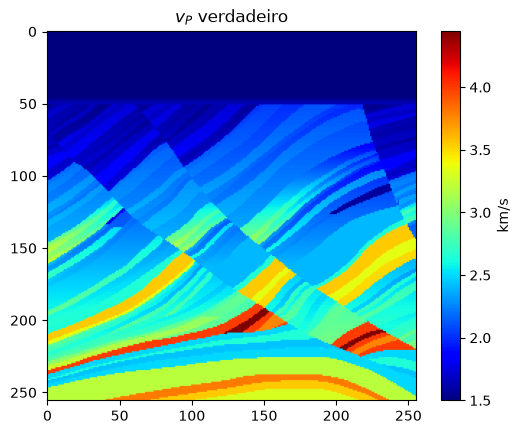

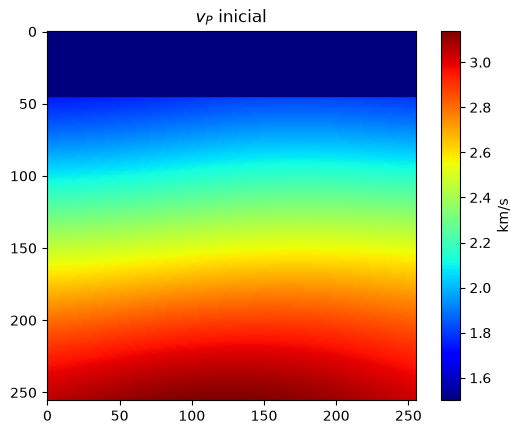

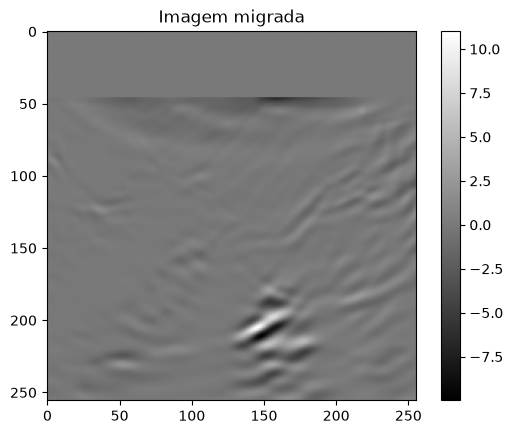

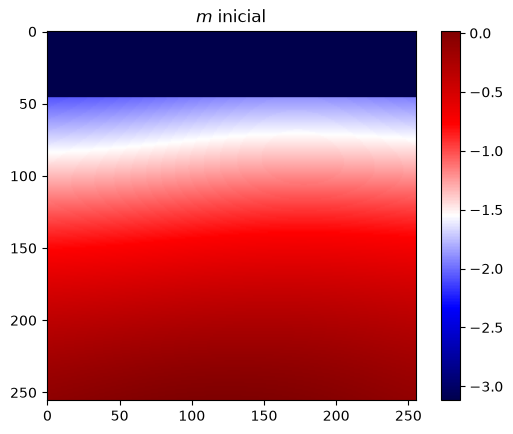

In [8]:
plot_image(vp_true, title='$v_P$ verdadeiro', label='km/s')
plot_image(vp_0, title='$v_P$ inicial', label='km/s')
plot_image(zeta, title='Imagem migrada', cmap='gray')
plot_image(m_0.numpy(), title='$m$ inicial', cmap='seismic')

## Construção da Rede

In [9]:
migmap = create_migration_map(*shape)

In [10]:
zeta_in = tf.constant(zeta)
np.min(zeta_in), np.max(zeta_in)

(np.float32(-9.987038), np.float32(11.037566))

In [11]:
dm = migmap(zeta_in)
np.min(dm), np.max(dm)

I0000 00:00:1782490739.989144  926449 cuda_dnn.cc:529] Loaded cuDNN version 91002


(np.float32(-5.4234076), np.float32(0.7305283))

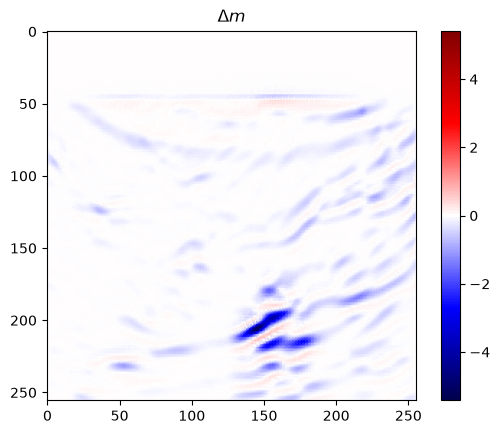

In [12]:
d = dm.numpy()
d = d - np.median(d)
plot_image(d, cmap='seismic', vmin=-np.abs(d).max(), vmax=np.abs(d).max(), title='$\\Delta m$')

## Operador de modelagem

In [13]:
nbl = 40

In [14]:
ap = AquisitionParameters.load('./data/aquisition-params.json')

nrec = ap.nrec
nsrc = ap.nsrc
nt = ap.nt

src_positions = ap.src_positions
ap.src_positions = np.zeros((1, 2))

In [15]:
vp0_pad = np.pad(vp_0[0, :, :, 0], nbl, mode='edge')
vp0_pad = vp0_pad.reshape((1, *vp0_pad.shape, 1))
damp_mask = generate_damp_mask(vp0_pad, nbl)

In [16]:
damp_mask.shape

(1, 336, 336, 1)

## Dado observado

In [17]:
dobs = np.fromfile('./data/dobs_nx256nz256dx10dz10.bin', dtype=np.float32).reshape(nsrc, nrec, nt)

In [18]:
slider = widgets.IntSlider(min=0, max=nsrc-1, description='Shot index')
@widgets.interact(idx=slider)
def plot_seismogram_interact(idx):
    plot_seismogram(dobs[idx], width, ap.tn)

interactive(children=(IntSlider(value=0, description='Shot index', max=4), Output()), _dom_classes=('widget-in…

## Inversão

In [19]:
migmap.input, migmap.output

(<KerasTensor shape=(None, 256, 256, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor>,
 <KerasTensor shape=(None, 256, 256, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_44>)

In [20]:
dm = migmap.output
m = layers.Add()([dm, m_0])
out = WaveSolverLayer(ap, damp_mask, src_positions, spacing=spacing)(m)
out

<KerasTensor shape=(5, 256, 4000), dtype=float32, sparse=False, ragged=False, name=keras_tensor_46>

In [21]:
model = Model(inputs=migmap.input,outputs=out,name='train_net')
model

<Functional name=train_net, built=True>

In [22]:
model.output

<KerasTensor shape=(5, 256, 4000), dtype=float32, sparse=False, ragged=False, name=keras_tensor_46>

In [23]:
with tf.GradientTape() as g:
    dcalc = model(zeta_in)
    res = dcalc - dobs
    phi = tf.reduce_mean(tf.square(res))

    grad = g.gradient(phi, model.variables[0])
grad

2026-06-26 13:22:47.796947: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 441.0KiB (rounded to 451584)requested by op Conv2D
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2026-06-26 13:22:47.797230: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1058] BFCAllocator dump for GPU_0_bfc
2026-06-26 13:22:47.797241: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1065] Bin (256): 	Total Chunks: 4491, Chunks in use: 4491. 1.10MiB allocated for chunks. 1.10MiB in use in bin. 86.2KiB client-requested in use in bin.
2026-06-26 13:22:47.797244: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1065] Bin (512): 	Total Chunks: 10, Chunks in use: 10. 5.0KiB allocated for chunks. 5.0KiB in use in bin. 4.8KiB client-requested in use in bin.
2026-06-

ResourceExhaustedError: Exception encountered when calling WaveSolverLayer.call().

[1m{{function_node __wrapped__Conv2D_device_/job:localhost/replica:0/task:0/device:GPU:0}} OOM when allocating tensor with shape[1,336,336,1] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:Conv2D] name: [0m

Arguments received by WaveSolverLayer.call():
  • vp_data=tf.Tensor(shape=(1, 256, 256, 1), dtype=float32)

In [ ]:
model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam()
)

In [ ]:
x_train = zeta
y_train = dobs.reshape((1, *dobs.shape))

In [ ]:
history = model.fit(
    x_train,
    y_train,
    batch_size=1,
    epochs=5
)